# K-Nearest Neighbors Regressor - Fish Weight Prediction

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 2. Load Dataset

In [2]:
df=pd.read_csv('fish.csv')
df.columns=df.columns.str.strip().str.lower()
df.head()

,species,weight,length1,length2,length3,height,width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


## 3. Explore Dataset

In [3]:
print(df.info())
print(df.describe())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   species  159 non-null    object 
 1   weight   158 non-null    float64
 2   length1  156 non-null    float64
 3   length2  152 non-null    float64
 4   length3  156 non-null    float64
 5   height   155 non-null    float64
 6   width    158 non-null    float64
dtypes: float64(6), object(1)
memory usage: 8.8+ KB
None
             weight     length1     length2     length3      height  \
count    158.000000  156.000000  152.000000  156.000000  155.000000   
mean     571.923418   26.235256   28.700658   31.165385    9.879736   
std     1412.917869   10.040909   10.726050   11.676360    9.091819   
min        0.000000    7.500000    8.400000    8.800000    1.728400   
25%      120.000000   19.000000   21.225000   23.025000    6.031600   
50%      281.500000   25.300000   27.500000   29.350000    7.786000   


## 4. Handle Missing Values

In [4]:
num_cols=df.select_dtypes(include='number').columns
imp=SimpleImputer(strategy='median')
df[num_cols]=imp.fit_transform(df[num_cols])
print(df.isnull().sum())

species    0
weight     0
length1    0
length2    0
length3    0
height     0
width      0
dtype: int64


## 5. Exploratory Data Analysis

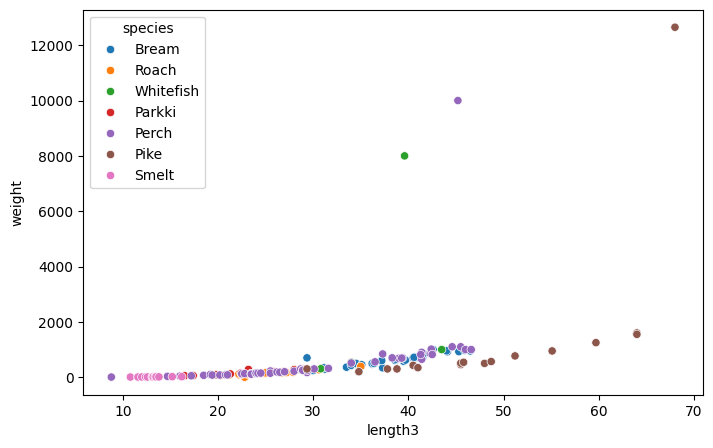

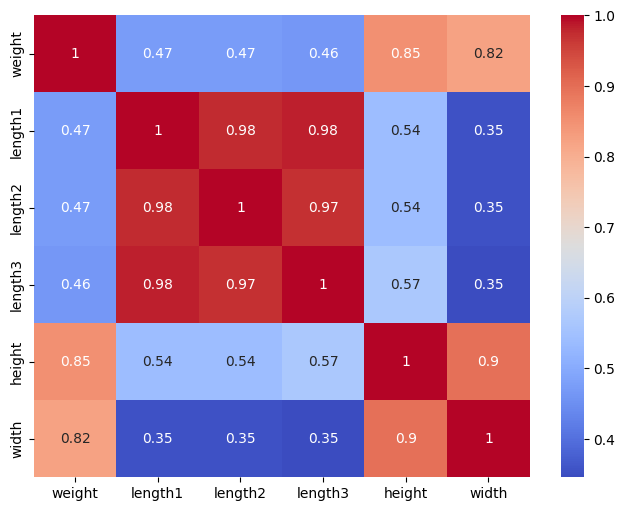

In [5]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df,x='length3',y='weight',hue='species')
plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes(include='number').corr(),annot=True,cmap='coolwarm')
plt.show()

## 6. Preprocessing

In [6]:
le=LabelEncoder()
df['species']=le.fit_transform(df['species'])
X=df.drop('weight',axis=1)
y=df['weight']
scaler=StandardScaler()
X=scaler.fit_transform(X)
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

## 7. Find Best k

In [7]:
scores={}
for k in range(1,16):
    m=KNeighborsRegressor(n_neighbors=k)
    m.fit(X_train,y_train)
    scores[k]=r2_score(y_test,m.predict(X_test))
best_k=max(scores,key=scores.get)
print(scores)
print("Best k:",best_k)

{1: 0.9061121404320349, 2: 0.8763169032966134, 3: 0.901522838298842, 4: 0.8995872397016693, 5: 0.9001605626799866, 6: 0.8810189989640814, 7: 0.8770410805584778, 8: 0.8906923891277364, 9: 0.8874937715572173, 10: 0.8877553249209542, 11: 0.8839391392510197, 12: 0.8805447271497604, 13: 0.8700985093416934, 14: 0.8594229261634243, 15: 0.8523421414698129}
Best k: 1


## 8. Train Model

In [8]:
model=KNeighborsRegressor(n_neighbors=best_k)
model.fit(X_train,y_train)
pred=model.predict(X_test)

## 9. Evaluation

In [9]:
mae=mean_absolute_error(y_test,pred)
mse=mean_squared_error(y_test,pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,pred)
print("="*45)
print("KNN Regressor Evaluation Metrics")
print("="*45)
print(f"Mean Absolute Error (MAE) : {mae:.2f}")
print(f"Mean Squared Error (MSE)  : {mse:.2f}")
print(f"Root Mean Squared Error   : {rmse:.2f}")
print(f"R² Score                  : {r2:.4f}")
print("="*45)

KNN Regressor Evaluation Metrics
Mean Absolute Error (MAE) : 60.80
Mean Squared Error (MSE)  : 13354.54
Root Mean Squared Error   : 115.56
R² Score                  : 0.9061


## 10. Metrics Explanation
- **MAE**: Average absolute prediction error.
- **MSE**: Average squared error.
- **RMSE**: Error in target units.
- **R²**: Proportion of variance explained.

## 11. Actual vs Predicted

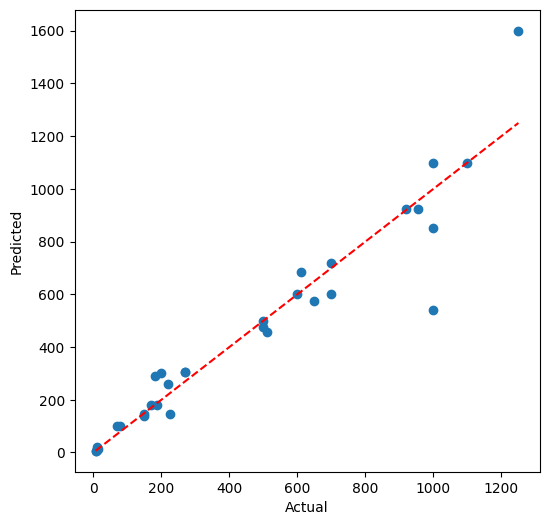

In [10]:
plt.figure(figsize=(6,6))
plt.scatter(y_test,pred)
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

## 12. Residual Plot

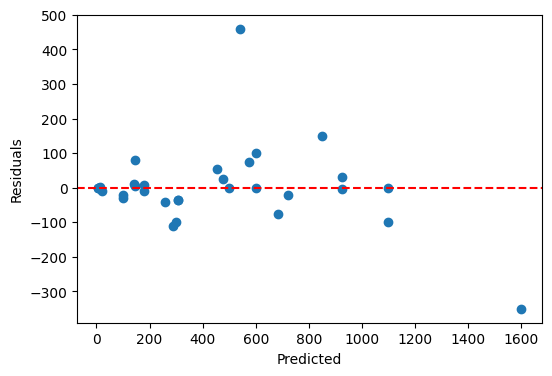

In [11]:
res=y_test-pred
plt.figure(figsize=(6,4))
plt.scatter(pred,res)
plt.axhline(0,color='r',linestyle='--')
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.show()

## 13. Key Findings

- Missing values in the dataset were handled using median imputation to ensure data quality.
- The categorical **Species** feature was converted into numerical values using Label Encoding.
- All input features were standardized using **StandardScaler**, which is essential for distance-based algorithms like K-Nearest Neighbors.
- The optimal number of neighbors was determined automatically by evaluating **k values from 1 to 15**, with **k = 1** providing the highest R² score.
- The model achieved an **R² score of 0.9061**, indicating that it explains approximately **90.6% of the variance** in fish weight.
- The low **MAE (60.80 g)** and **RMSE (115.56 g)** demonstrate that the model predicts fish weight with good accuracy.
- The project illustrates how KNN Regression effectively captures relationships between fish measurements and weight without assuming a linear relationship.

## 14. Conclusion

In this project, a **K-Nearest Neighbors Regressor** was developed to predict fish weight based on physical measurements. The workflow included data exploration, missing value handling, categorical feature encoding, feature scaling, automatic selection of the optimal value of **k**, model training, and performance evaluation.

The model achieved an **R² score of 0.9061**, demonstrating excellent predictive capability by explaining over **90% of the variation** in fish weight. These results highlight the effectiveness of KNN Regression for datasets where observations with similar feature values tend to have similar target values.

Overall, this project demonstrates the complete implementation of a distance-based regression algorithm and showcases best practices in preprocessing, model selection, evaluation, and visualization, making it a valuable addition to a machine learning portfolio.